## In Class Activity April 21
### Dirks Wright


In [1]:
### import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sweetviz as sv

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


In [2]:
### load dataset
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
### sweetviz report
report = sv.analyze(adult)
report.show_html("adult_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report adult_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


<Figure size 800x400 with 0 Axes>

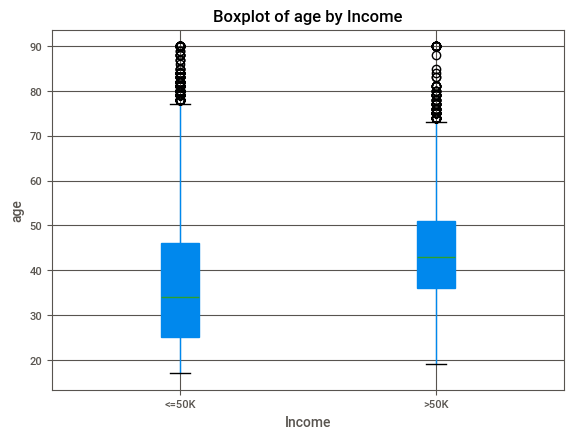

<Figure size 800x400 with 0 Axes>

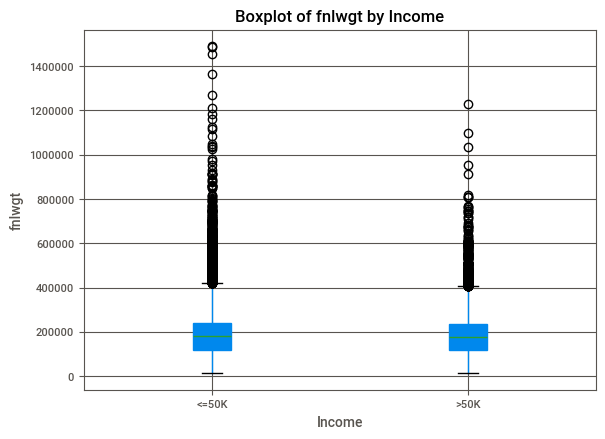

<Figure size 800x400 with 0 Axes>

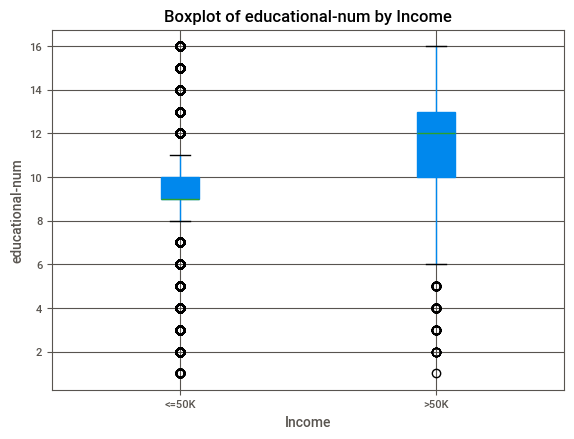

<Figure size 800x400 with 0 Axes>

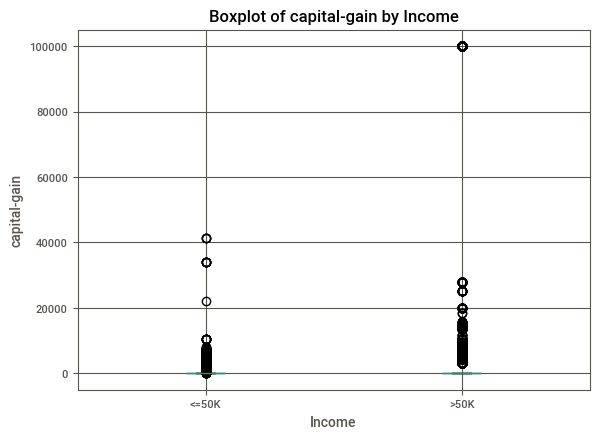

<Figure size 800x400 with 0 Axes>

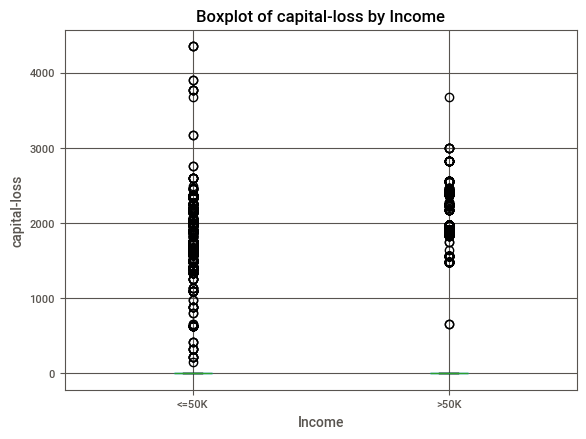

<Figure size 800x400 with 0 Axes>

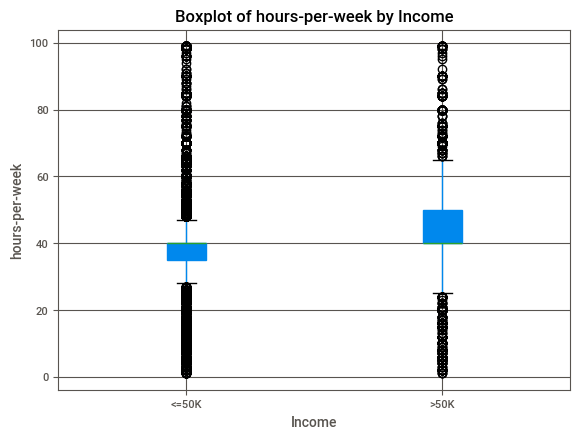

In [4]:
### EDA boxplots for numeric features and target variable income
### add color and make it look professional

numeric_features = adult.select_dtypes(include=["int64", "float64"]).columns
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    bp = adult.boxplot(column=feature, by="income", patch_artist=True)
    
    colors = ["lightblue", "salmon"]
    for box, color in zip(bp.artists, colors):
        box.set_facecolor(color)
    plt.title(f"Boxplot of {feature} by Income")
    plt.suptitle("")
    plt.xlabel("Income")
    plt.ylabel(feature)
    plt.show()

    

<Figure size 1000x500 with 0 Axes>

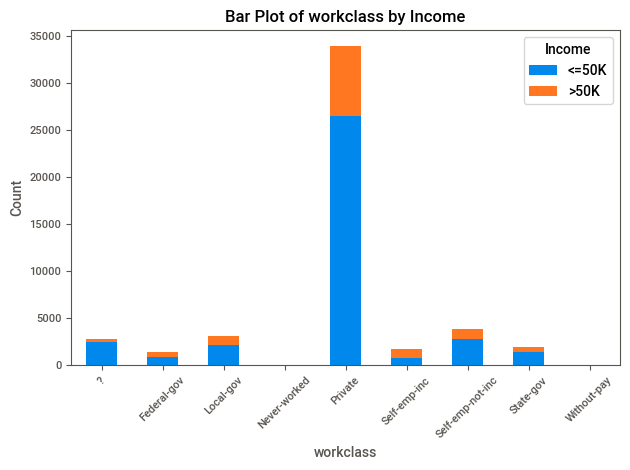

<Figure size 1000x500 with 0 Axes>

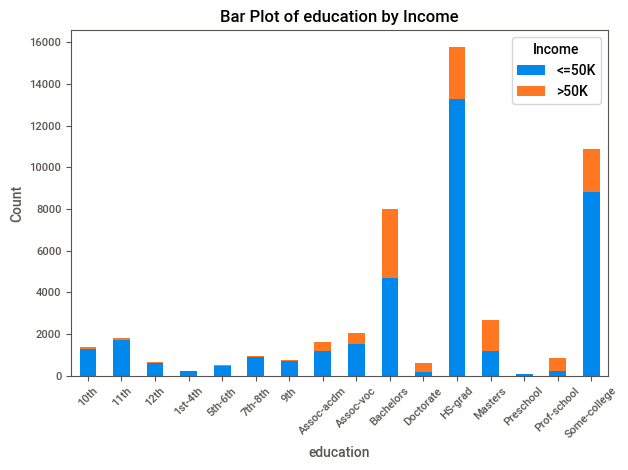

<Figure size 1000x500 with 0 Axes>

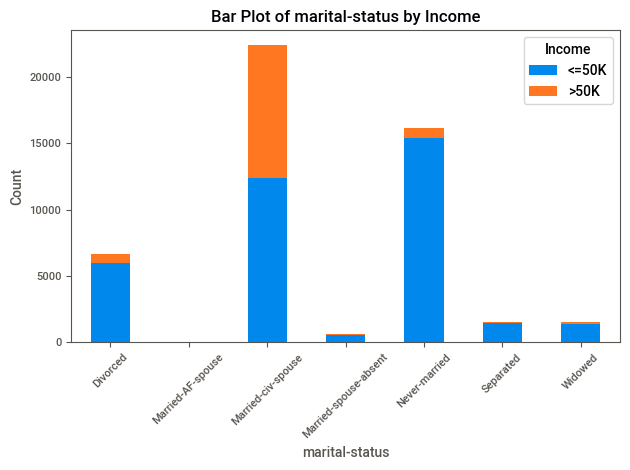

<Figure size 1000x500 with 0 Axes>

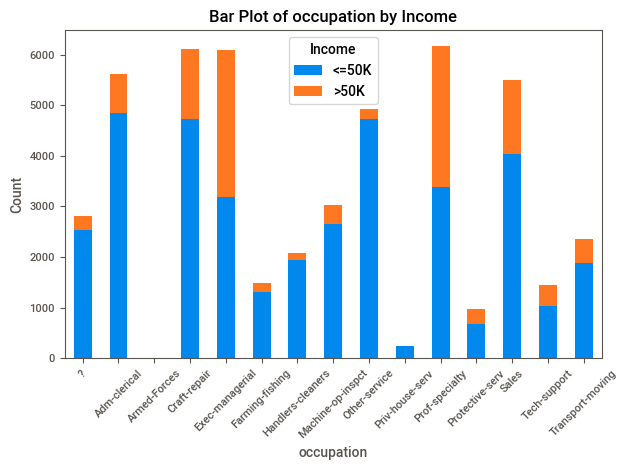

<Figure size 1000x500 with 0 Axes>

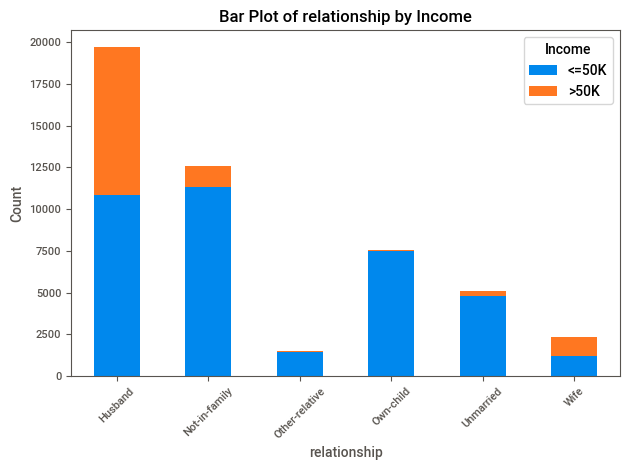

<Figure size 1000x500 with 0 Axes>

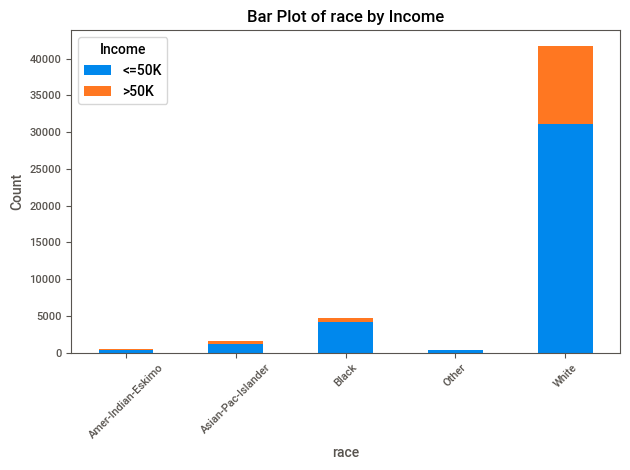

<Figure size 1000x500 with 0 Axes>

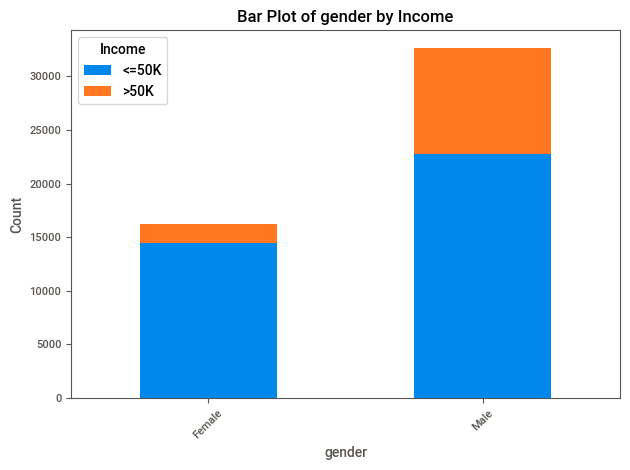

<Figure size 1000x500 with 0 Axes>

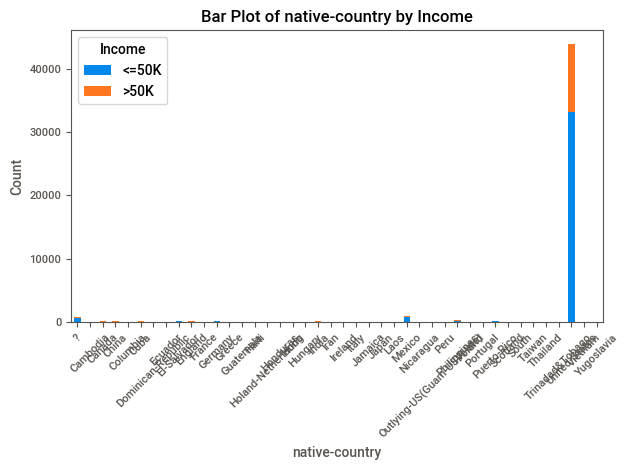

In [5]:
### EDA Bar plots for categorical features and target variable income
categorical_features = adult.select_dtypes(include=["object"]).columns.drop("income")
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    adult.groupby([feature, "income"]).size().unstack().plot(kind="bar", stacked=True)
    plt.title(f"Bar Plot of {feature} by Income")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Income")
    plt.tight_layout()
    plt.show()

In [6]:
# Basic cleaning used by both models
adult = adult.replace("?", np.nan)
adult["income"] = adult["income"].map({">50K": 1, "<=50K": 0})
adult["gender"] = adult["gender"].map({"Male": 1, "Female": 0})

adult.isna().sum().sort_values(ascending=False).head(10)

occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
dtype: int64

In [7]:
def add_features(df):
    df = df.copy()
    df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
    df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)
    df["capital_total"] = df["capital-gain"] + df["capital-loss"]
    df["capital_net"] = df["capital-gain"] - df["capital-loss"]
    df["hours_per_age"] = df["hours-per-week"] / df["age"].clip(lower=1)
    df["education_hours_interaction"] = df["educational-num"] * df["hours-per-week"]
    df["is_married"] = df["marital-status"].fillna("Unknown").str.contains("Married").astype(int)
    return df

adult_fe = add_features(adult)
adult_fe[[
    "capital_total",
    "capital_net",
    "hours_per_age",
    "education_hours_interaction",
    "is_married"
]].head()

,capital_total,capital_net,hours_per_age,education_hours_interaction,is_married
0,0,0,1.600000,280,0
1,0,0,1.315789,450,1
2,0,0,1.428571,480,1
3,7688,7688,0.909091,400,1
4,0,0,1.666667,300,0


In [8]:
X = adult_fe.drop(columns=["income", "fnlwgt", "education"])
y = adult_fe["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Train shape: (39073, 19)
Test shape: (9769, 19)
Numeric features: 13
Categorical features: 6


## Two Models


In [9]:
### model 1 logistic regression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

logistic_pipe = Pipeline([
    ("prep", logistic_preprocessor),
    ("model", LogisticRegression(max_iter=4000, solver="saga"))
])

logistic_params = {
    "model__C": np.logspace(-2, 1, 8),
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipe,
    param_distributions=logistic_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

logistic_search.fit(X_train, y_train)
best_logistic = logistic_search.best_estimator_

print("Best logistic params:")
print(logistic_search.best_params_)
print("Best logistic CV ROC AUC:", round(logistic_search.best_score_, 4))

Best logistic params:
{'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': np.float64(0.19306977288832497)}
Best logistic CV ROC AUC: 0.911


Top Logistic Regression Features
                                      feature  coefficient  abs_coefficient
8                          num__capital_total     1.600185         1.600185
3                           num__capital-gain     1.556547         1.556547
24  cat__marital-status_Married-spouse-absent    -1.528937         1.528937
9                            num__capital_net     1.508252         1.508252
10                         num__hours_per_age    -1.038380         1.038380
32            cat__occupation_Farming-fishing    -1.026802         1.026802
5                         num__hours-per-week     1.017211         1.017211
35              cat__occupation_Other-service    -0.902183         0.902183
36            cat__occupation_Priv-house-serv    -0.888994         0.888994
45                cat__relationship_Own-child    -0.871832         0.871832
44           cat__relationship_Other-relative    -0.857809         0.857809
56               cat__native-country_Columbia    -0.814

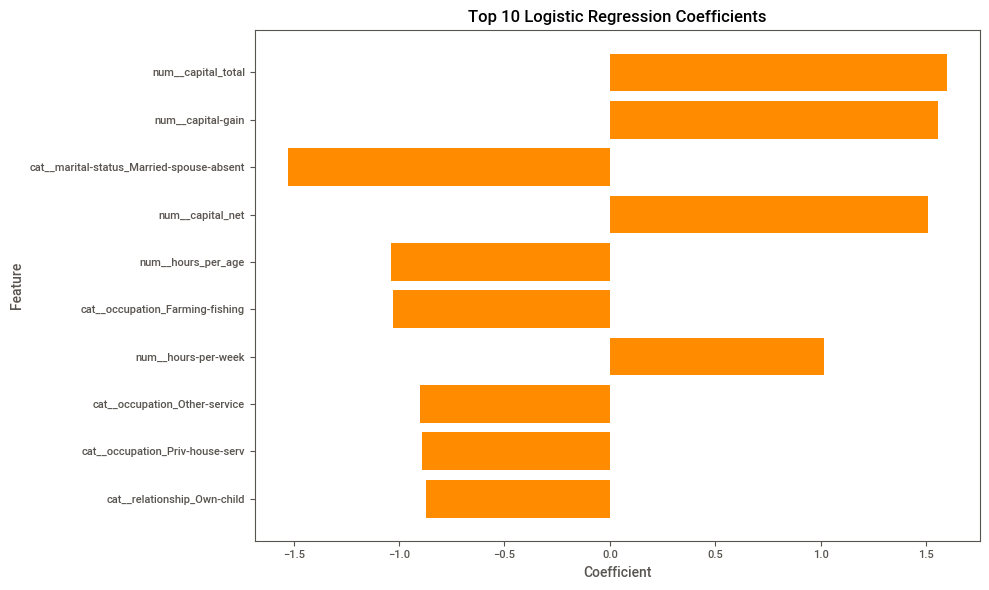

In [10]:
# Coefficient importance for the tuned logistic regression
logistic_feature_names = best_logistic.named_steps["prep"].get_feature_names_out()
logistic_coefficients = best_logistic.named_steps["model"].coef_[0]

logistic_importance_df = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_coefficients,
    "abs_coefficient": np.abs(logistic_coefficients)
}).sort_values("abs_coefficient", ascending=False)

print("Top Logistic Regression Features")
print(logistic_importance_df.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    logistic_importance_df["feature"].head(10)[::-1],
    logistic_importance_df["coefficient"].head(10)[::-1],
    color="darkorange"
)
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [11]:
### model 2 random forest
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
            ]),
            categorical_features
        )
    ]
)

rf_pipe = Pipeline([
    ("prep", rf_preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best random forest params:")
print(rf_search.best_params_)
print("Best random forest CV ROC AUC:", round(rf_search.best_score_, 4))

Best random forest params:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 20, 'model__class_weight': 'balanced'}
Best random forest CV ROC AUC: 0.9204


Top Random Forest Features
             feature  importance
12  has_capital_gain    0.174399
11    native-country    0.120904
16     hours_per_age    0.107770
14     capital_total    0.095089
0                age    0.092448
1          workclass    0.082149
8       capital-gain    0.054193
9       capital-loss    0.052734
10    hours-per-week    0.050289
3     marital-status    0.040672
15       capital_net    0.033538
5       relationship    0.031167
13  has_capital_loss    0.015531
4         occupation    0.015136
2    educational-num    0.009479


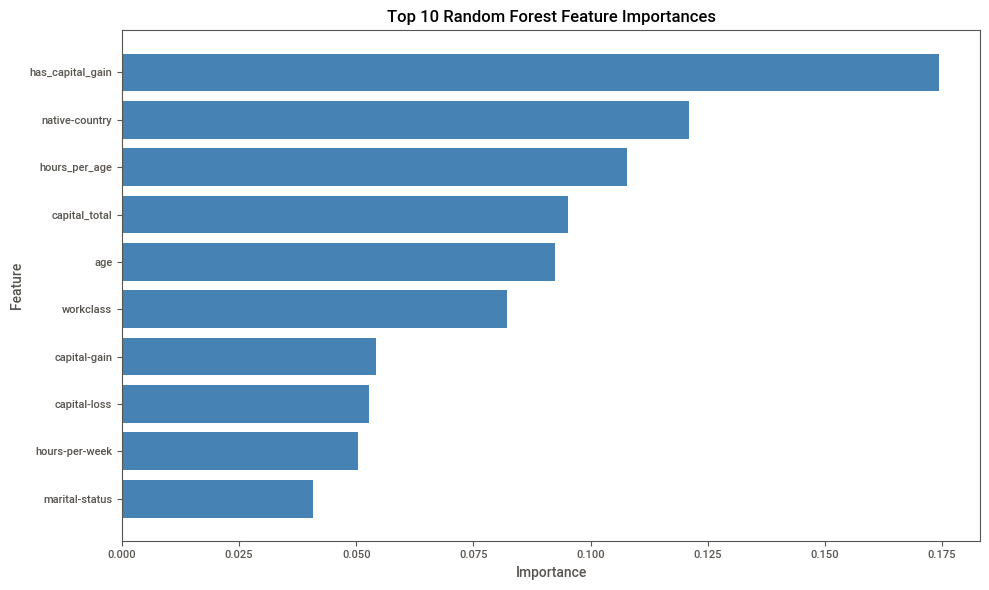

In [12]:
# Feature importance for the tuned random forest
rf_feature_names = X_train.columns
rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": best_rf.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("Top Random Forest Features")
print(rf_importance_df.head(15))

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["feature"].head(10)[::-1], rf_importance_df["importance"].head(10)[::-1], color="steelblue")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [13]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    print(f"{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"{name} ROC AUC: {roc_auc_score(y_test, probs):.4f}")
    print(classification_report(y_test, preds))
    return preds, probs

logistic_pred, logistic_probs = evaluate_model("Logistic Regression", best_logistic, X_test, y_test)
rf_pred, rf_probs = evaluate_model("Random Forest", best_rf, X_test, y_test)

Logistic Regression Accuracy: 0.8119
Logistic Regression ROC AUC: 0.9104
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      7431
           1       0.57      0.85      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.81      0.82      9769

Random Forest Accuracy: 0.8396
Random Forest ROC AUC: 0.9232
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7431
           1       0.62      0.83      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.84      0.85      9769



In [14]:
# Equal-weight probability averaging
ensemble_probs = (logistic_probs + rf_probs) / 2
ensemble_pred = (ensemble_probs >= 0.5).astype(int)

print("Ensemble Accuracy:", round(accuracy_score(y_test, ensemble_pred), 4))
print("Ensemble ROC AUC:", round(roc_auc_score(y_test, ensemble_probs), 4))
print(classification_report(y_test, ensemble_pred))

Ensemble Accuracy: 0.8285
Ensemble ROC AUC: 0.9223
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7431
           1       0.60      0.85      0.70      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.83      0.79      9769
weighted avg       0.86      0.83      0.84      9769



In [15]:
results = pd.DataFrame({
    "model": ["Tuned Logistic Regression", "Tuned Random Forest", "Probability Averaged Ensemble"],
    "accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ensemble_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_test, logistic_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, ensemble_probs)
    ]
}).sort_values("roc_auc", ascending=False)

results

,model,accuracy,roc_auc
1,Tuned Random Forest,0.839595,0.923245
2,Probability Averaged Ensemble,0.828539,0.922273
0,Tuned Logistic Regression,0.811854,0.910367


### Results

I found that the engineered capital features (capital_total, capital_net, and has_capital_gain) plus hours_per_age were the most useful predictors. The random forest performed best overall, while logistic regression was easier to interpret. The ensemble improved performance a bit by averaging the two models’ probability estimates, which helped capture complementary strengths. The models did respond differently to engineered features: logistic regression relied more on continuous engineered variables, while the random forest also gave strong signal to binary/categorical-derived features like has_capital_gain and native-country. In my workflow, I would keep creating both continuous and indicator-style engineered features, evaluate them with linear and tree-based models, and use ensembles when they improve validation performance.